# One-hidden-layer neural network from scratch

## Objective

Build and train a $2\rightarrow2\rightarrow1$ neural network using only NumPy. The hidden layer uses $\tanh$ and the output uses sigmoid:

$$
\mathbf Z_1=\mathbf X\mathbf W_1+\mathbf b_1,
\qquad
\mathbf A_1=\tanh(\mathbf Z_1),
$$

$$
\mathbf Z_2=\mathbf A_1\mathbf W_2+b_2,
\qquad
\hat{\mathbf y}=\sigma(\mathbf Z_2).
$$

We will train the network on XOR, which cannot be separated by the single straight decision boundary available to one sigmoid neuron. The nonlinear hidden representation allows the network to construct a nonlinear decision boundary.

We will explicitly implement initialization, forward propagation, binary cross-entropy, multilayer backpropagation, and gradient-descent updates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## XOR training data

$$
y=x_1\oplus x_2
$$

XOR is $1$ exactly when its two binary inputs differ.

In [2]:
X = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y = np.array([[0.0], [1.0], [1.0], [0.0]])

In [3]:
display(X)
print("")
display(y)

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]])

array([[0.],
       [1.],
       [1.],
       [0.]])

## Parameter shapes and symmetry breaking

| Parameter | Shape | Connection |
| --- | --- | --- |
| $\mathbf W_1$ | $(2,2)$ | inputs $\rightarrow$ hidden layer |
| $\mathbf b_1$ | $(1,2)$ | hidden-layer biases |
| $\mathbf W_2$ | $(2,1)$ | hidden layer $\rightarrow$ output |
| $b_2$ | $(1,1)$ | output bias |

Initialize weights randomly with a scale based on their number of inputs, while biases may start at zero:

$$
W_{jk}^{(\ell)}\sim\mathcal N\!\left(0,\frac{1}{n_{\ell-1}}\right),
\qquad
\mathbf b^{(\ell)}=0.
$$

If all hidden neurons start with identical weights, they receive identical gradients and remain identical. Random weights break this symmetry so the two neurons can learn different features.

In [4]:
rng = np.random.default_rng(42)

n_input_1 = 2
variance_1 = 1.0 / n_input_1
std_dev_1 = np.sqrt(variance_1)

shape_W1 = (2, 2)
W1 = std_dev_1 * rng.standard_normal(shape_W1)
shape_b1 = (1, 2)
b1 = np.zeros(shape_b1)

n_input_2 = 2
variance_2 = 1.0 / n_input_2
std_dev_2 = np.sqrt(variance_2)

shape_W2 = (2, 1)
W2 = std_dev_2 * rng.standard_normal(shape_W2)
shape_b2 = (1, 1)
b2 = np.zeros(shape_b2)


## Forward propagation

$$
\mathbf Z_1=\mathbf X\mathbf W_1+\mathbf b_1,
\qquad
\mathbf A_1=\tanh(\mathbf Z_1),
$$

$$
\mathbf Z_2=\mathbf A_1\mathbf W_2+b_2,
\qquad
\hat{\mathbf y}=\sigma(\mathbf Z_2).
$$

The hidden activation has shape $(4,2)$; the output probability has shape $(4,1)$.

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [6]:
Z1 = X @ W1 + b1
A1 = np.tanh(Z1)
Z2 = A1 @ W2 + b2
y_hat = sigmoid(Z2)

In [7]:
display(Z1)
print("")
display(A1)
print("")
display(Z2)
print("")
display(y_hat)
print("")

array([[ 0.        ,  0.        ],
       [ 0.53064913,  0.66507969],
       [ 0.21546751, -0.73537981],
       [ 0.74611664, -0.07030012]])

array([[ 0.        ,  0.        ],
       [ 0.48587713,  0.58173399],
       [ 0.21219384, -0.62634564],
       [ 0.63282648, -0.07018454]])

array([[ 0.        ],
       [-1.20596034],
       [ 0.28398596],
       [-0.8084167 ]])

array([[0.5       ],
       [0.2304166 ],
       [0.57052316],
       [0.30822799]])

In [8]:
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    y_hat = sigmoid(Z2)

    return y_hat, {"Z1": Z1, "A1": A1, "Z2": Z2}

In [9]:
y_hat_2, cache = forward(X, W1, b1, W2, b2)

In [10]:
display(np.allclose(y_hat_2, y_hat))
display(np.allclose(cache["Z1"], Z1))
display(np.allclose(cache["A1"], A1))
display(np.allclose(cache["Z2"], Z2))

True

True

True

True

## Binary cross-entropy loss

$$
J=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat y_i)+(1-y_i)\log(1-\hat y_i)\right].
$$

In [11]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred_clip = y_pred.clip(eps, 1 - eps)

    loss = -( y_true * np.log(y_pred_clip) + (1.0 - y_true) * np.log(1.0 - y_pred_clip))
    return np.mean(loss)

In [12]:
initial_loss = binary_cross_entropy(y, y_hat_2)

display(initial_loss)

np.float64(0.7726784564210807)

## Backpropagation through both layers

Write $d\mathbf Z_\ell=\partial J/\partial\mathbf Z_\ell$. For sigmoid with binary cross-entropy, the output-layer result derived in notebook 01 gives

$$
d\mathbf Z_2=\frac{1}{N}(\hat{\mathbf y}-\mathbf y).
$$

Because $\mathbf Z_2=\mathbf A_1\mathbf W_2+b_2$,

$$
d\mathbf W_2=\mathbf A_1^{\mathsf T}d\mathbf Z_2,
\qquad
db_2=\sum_{i=1}^{N}dZ_{2,i}.
$$

Propagate the error through the second weight matrix:

$$
d\mathbf A_1=d\mathbf Z_2\mathbf W_2^{\mathsf T}.
$$

Since $\mathbf A_1=\tanh(\mathbf Z_1)$ and $\tanh'(z)=1-\tanh^2(z)$, the chain rule is applied separately to every training example $i$ and hidden neuron $j$:

$$
(dZ_1)_{ij}=(dA_1)_{ij}\left[1-(A_1)_{ij}^2\right].
$$

Equivalently, let $\mathbf 1_{N\times2}$ be an array of ones with the same shape as $\mathbf A_1$. Then

$$
d\mathbf Z_1=d\mathbf A_1\odot\left(\mathbf 1_{N\times2}-\mathbf A_1\odot\mathbf A_1\right).
$$

Every multiplication marked $\odot$ is elementwise; there is no matrix square or matrix multiplication in this step.

Finally, because $\mathbf Z_1=\mathbf X\mathbf W_1+\mathbf b_1$,

$$
d\mathbf W_1=\mathbf X^{\mathsf T}d\mathbf Z_1,
\qquad
d\mathbf b_1=\sum_{i=1}^{N}d\mathbf Z_{1,i}.
$$

The factor $1/N$ is already included in $d\mathbf Z_2$, so the later gradients must not be divided by $N$ again.

In [13]:
def backward(X, y, y_hat, cache, W2):
    dZ2 = (1.0 / y.shape[0]) * (y_hat - y)
    dW2 = cache["A1"].T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (1.0 - cache["A1"]**2)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
        
    gradient = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2,
    }
    return gradient

In [14]:
display(backward(X, y, y_hat_2, cache, W2))

{'dW1': array([[ 0.07772163, -0.01052461],
        [ 0.13903188,  0.04659965]]),
 'db1': array([[ 0.10803908, -0.00841942]]),
 'dW2': array([[-0.06750012],
        [-0.05008118]]),
 'db2': array([[-0.09770806]])}

## One gradient-descent update

Apply the same update independently to every weight matrix and bias:

$$
\theta\leftarrow\theta-\eta\frac{\partial J}{\partial\theta},
\qquad
\theta\in\{\mathbf W_1,\mathbf b_1,\mathbf W_2,b_2\}.
$$

In [15]:
gradients = backward(X, y, y_hat_2, cache, W2)
learning_rate = 0.1

updated_W1 = W1 - learning_rate * gradients["dW1"]
updated_b1 = b1 - learning_rate * gradients["db1"]
updated_W2 = W2 - learning_rate * gradients["dW2"]
updated_b2 = b2 - learning_rate * gradients["db2"]


y_hat_new, cache_new = forward(X, updated_W1, updated_b1, updated_W2, updated_b2)

loss_new = binary_cross_entropy(y, y_hat_new)

display(loss_new)
display(y_hat_new)

np.float64(0.7672120105751296)

array([[0.50595753],
       [0.23840259],
       [0.57821353],
       [0.31757847]])

## Training loop

Each epoch performs a complete forward pass, evaluates the loss, backpropagates through both layers, and updates all four parameter arrays:

$$
\text{forward}\;\longrightarrow\;\text{loss}\;\longrightarrow\;\text{backward}\;\longrightarrow\;\text{update}.
$$

In [16]:
W1_train = W1.copy()
b1_train = b1.copy()
W2_train = W2.copy()
b2_train = b2.copy()

learning_rate = 0.1
num_epochs = 10_000

loss_history = []

for epoch in range(num_epochs):
    y_hat_train, cache_train = forward(X, W1_train, b1_train, W2_train, b2_train)
    loss = binary_cross_entropy(y, y_hat_train)
    loss_history.append(loss)
    gradients = backward(X, y, y_hat_train, cache_train, W2_train)

    W1_train = W1_train - learning_rate * gradients["dW1"]
    b1_train = b1_train - learning_rate * gradients["db1"]
    W2_train = W2_train - learning_rate * gradients["dW2"]
    b2_train = b2_train - learning_rate * gradients["db2"]
    

y_hat_train, cache_train = forward(X, W1_train, b1_train, W2_train, b2_train)
display(y_hat_train)
print("")

predictions = np.where(y_hat_train >= 0.5, 1, 0)
display(predictions)
print("")

final_loss = binary_cross_entropy(y, y_hat_train)
display(final_loss)
print("")


array([[0.00241364],
       [0.99568906],
       [0.99571385],
       [0.00207069]])

array([[0],
       [1],
       [1],
       [0]])

np.float64(0.003276252920241698)

## Learning curve

The loss history shows whether the complete two-layer optimization converges smoothly.

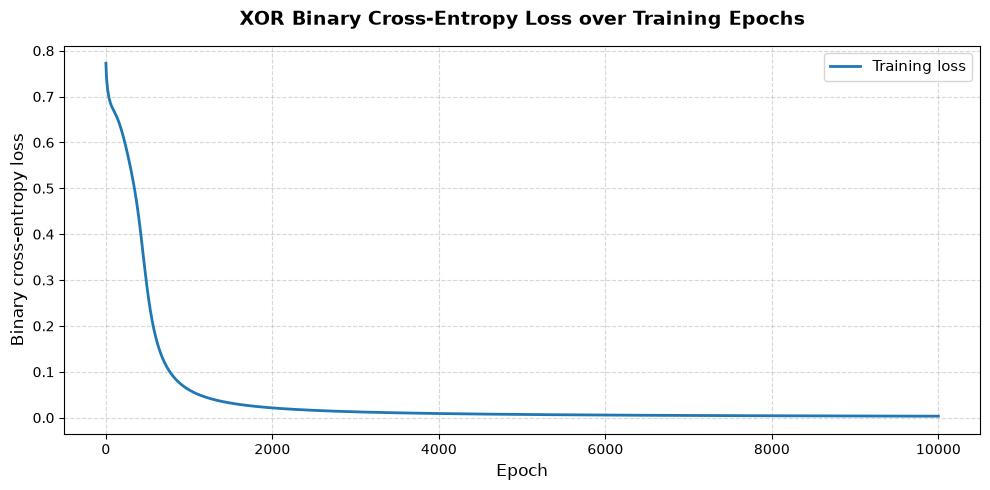

In [17]:
epoch_axis = range(1, len(loss_history) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoch_axis, loss_history, color="#1f77b4", linewidth=2, label="Training loss")
plt.title("XOR Binary Cross-Entropy Loss over Training Epochs", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary cross-entropy loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Learned nonlinear decision surface

The contour $\hat y=0.5$ separates the two predicted classes. Unlike the single-neuron boundary, it need not be one straight line because the output acts on nonlinear hidden features.

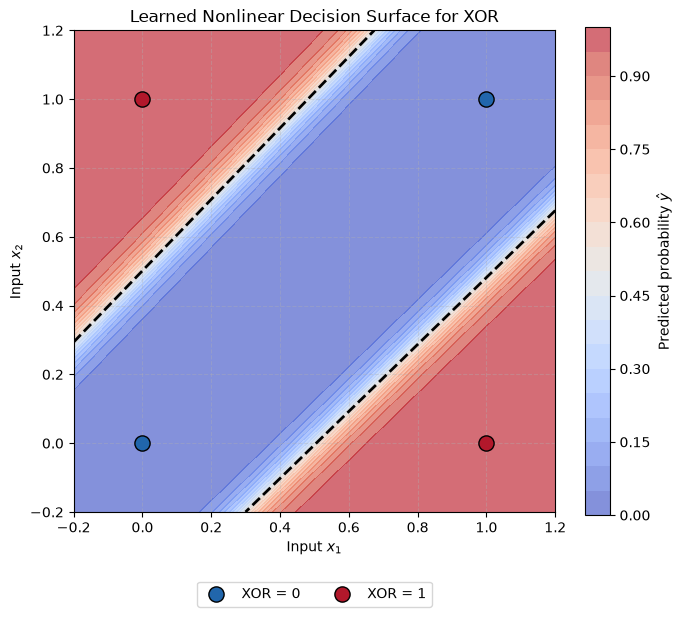

In [18]:
x1_values = np.linspace(-0.2, 1.2, 300)
x2_values = np.linspace(-0.2, 1.2, 300)
x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)
grid_points = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
grid_probabilities, _ = forward(grid_points, W1_train, b1_train, W2_train, b2_train)
probability_grid = grid_probabilities.reshape(x1_grid.shape)

fig, ax = plt.subplots(figsize=(7, 6))
probability_map = ax.contourf(
    x1_grid, x2_grid, probability_grid,
    levels=np.linspace(0.0, 1.0, 21), cmap="coolwarm", alpha=0.65,
)
fig.colorbar(probability_map, ax=ax, label=r"Predicted probability $\hat{y}$")
ax.contour(
    x1_grid, x2_grid, probability_grid,
    levels=[0.5], colors="black", linewidths=2, linestyles="--",
)

negative = y.ravel() == 0
positive = y.ravel() == 1
ax.scatter(
    X[negative, 0], X[negative, 1],
    s=120, color="#2166ac", edgecolor="black", label="XOR = 0", zorder=3,
)
ax.scatter(
    X[positive, 0], X[positive, 1],
    s=120, color="#b2182b", edgecolor="black", label="XOR = 1", zorder=3,
)

ax.set(
    xlim=(-0.2, 1.2), ylim=(-0.2, 1.2),
    xlabel=r"Input $x_1$", ylabel=r"Input $x_2$",
    title="Learned Nonlinear Decision Surface for XOR",
)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
plt.tight_layout()
plt.show()

## Conclusion

The single sigmoid neuron could solve OR because OR is linearly separable. XOR required two nonlinear hidden features:

$$
\mathbf X\longrightarrow\mathbf A_1=\tanh(\mathbf X\mathbf W_1+\mathbf b_1)\longrightarrow\hat{\mathbf y}.
$$

In the learned hidden representation, the output neuron can separate the classes even though no single straight boundary can separate them in the original input space.